In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Now you can access your Google Drive files at '/content/drive/My Drive'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!ls /content/drive/MyDrive  # Lists files in your Google Drive

 0324_DNA_Translation_and_Codons.jpg
 06022025121830-0001.pdf
 13.pdf
'18-Female presence in corporate governance.pdf'
 1-s2.0-S0040162521005576-main.pdf
 1-s2.0-S0360132321006004-main.pdf
 1-s2.0-S2211467X24001731-main.pdf
'1. 에너지자급자족 사업 참여기업 에너지 데이터.zip'
 2021FirmsAttribute.pdf
'2025 Goal.gdoc'
'2025 Weekly Report'
'21-32_FUJAFR_Yusuf+&+Musa_2025_v3_i3_191.pdf'
'2502-Article Text-6828-1-10-20250419.pdf'
 3-2.mp4
'3. 구미산단 에너지자급자족을 위한 기업조사 설문데이터.zip'
 4-1.mp4
 46624-146848-1-SM.pdf
 5.mp4
'629-Article Text-1168-1-10-20220509.pdf'
 6301-AEFR2025152256-266Iraq.pdf
 94126.pdf
 A_Blockchain-Based_Peer-to-Peer_Trading_Scheme_Coupling_Energy_and_Carbon_Markets.pdf
'Acknowledgment list N17 .png'
'Advanced Adaptive cruise control system.gdoc'
 Ajakwe_Ihunanya-_CV-2pages.pdf
'Ajakwe Ihunanya Udodiri, ITRC-Pure certificate.gslides'
'AjakweIU Photo.jpg'
 ajfPaper2.pdf
 ALL
'ALL 5 NATIONS.png'
'annual-co2-emissions-per-country (1).zip'
'Appli

In [ ]:
import os

# Define the path to your folder (modify as needed)
folder_path = "/content/drive/MyDrive/ICTC 2025"

# Change to the target directory
os.chdir(folder_path)

# Verify the current working directory
print("Current Directory:", os.getcwd())

# List files in the directory
print("Files in Directory:", os.listdir())

Current Directory: /content/drive/MyDrive/ICTC 2025
Files in Directory: ['Drone-DAG-Simulation.ipynb', 'GPS_Data_Simplified_2D_Feature_Map.xlsx', 'outputs', 'FL-SHAP.ipynb', 'Modified-FL-SHAP.ipynb', 'outputs-CNN-GRU-LSTM', 'CNN-GRU-LSTM-FL-SHAP.ipynb', 'outputs-CNN', 'CNN-FL-SHAP.ipynb', 'outputs-LSTM', 'outputs-CNN2', 'LSTM-FL-SHAP.ipynb', 'GPS_Data_Simplified_2D_Feature_Map.csv', 'BalancedDataset-CNN-FL-SHAP.ipynb', 'EDA.ipynb']


In [ ]:
pip install pandas numpy scikit-learn tensorflow openpyxl matplotlib seaborn


In [ ]:
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, confusion_matrix, roc_auc_score, roc_curve
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [ ]:
# data needs not to be downloaded separately
df=pd.read_excel('/content/drive/MyDrive/ICTC 2025/GPS_Data_Simplified_2D_Feature_Map.xlsx')
df.head()

,PRN,DO,PD,RX,TOW,CP,EC,LC,PC,PIP,PQP,TCD,CN0,Output
0,6,1160.671408,-238359.543282,491568.00,491568.000795,-24660.263293,163521.78,170008.81,179294.97,178420.33,-17688.17800,1158.4806,49.412529,0
1,6,1157.827808,-238363.921192,491568.02,491568.020795,-24683.468520,158277.05,160253.09,182106.11,182106.05,158.33333,1160.7948,49.452686,0
2,6,1161.135932,-238368.638615,491568.04,491568.040795,-24706.687357,184442.36,193125.89,208228.02,-205198.30,35391.59000,1157.6909,49.480145,0
3,6,1161.156617,-238373.391775,491568.06,491568.060795,-24729.920039,159812.45,169960.55,187550.72,187543.00,-1701.94400,1161.1343,49.433769,0
4,6,1160.690893,-238378.127066,491568.08,491568.080795,-24753.153999,183557.66,191912.58,208403.50,208330.05,-5532.89990,1161.1759,49.391670,0


In [ ]:
df.describe()

,PRN,DO,PD,RX,TOW,CP,EC,LC,PC,PIP,PQP,TCD,CN0,Output
count,510530.000000,510530.000000,5.105300e+05,510530.000000,510530.000000,5.105300e+05,510530.000000,510530.000000,510530.000000,510530.000000,510530.000000,510530.000000,510530.000000,510530.000000
mean,14.399743,1293.270723,7.992497e+06,282666.233354,282666.208111,-1.216893e+05,107973.452869,107946.509101,119563.129474,39.357453,65.535775,1303.725859,44.717167,0.432819
std,9.279444,2362.534207,1.006911e+07,106925.234281,106925.232122,2.398627e+05,31711.904090,31572.262598,34068.953790,122138.198997,24318.316229,2348.382188,2.909404,0.891641
min,2.000000,-4262.754835,-6.588428e+06,173640.000000,173640.008000,-1.032332e+06,-11261.148740,-12557.513790,318.674133,-270777.625000,-216012.859900,-3214.671400,0.000000,0.000000
25%,7.000000,-868.884393,2.374256e+06,174220.600000,174220.522000,-2.560281e+05,86407.752045,86486.361330,96580.286923,-119618.003925,-11904.076640,-864.922714,43.203264,0.000000
50%,11.000000,1425.205130,3.777471e+06,263290.160000,263290.145050,-9.741575e+04,109815.675800,109799.156250,121863.750000,-339.778535,35.455368,1472.187866,45.346006,0.000000
75%,26.000000,3451.204770,6.814777e+06,263799.780000,263799.770600,6.364966e+04,130963.429675,130794.406300,144362.848125,119631.968800,11955.028080,3444.271612,46.691953,0.000000
max,31.000000,6715.759846,2.830762e+07,492039.420000,492039.341092,3.527992e+05,244872.734400,244650.390600,271466.125000,242361.078100,226761.110000,5260.343750,50.482834,3.000000


In [ ]:
df['Output'].unique()

array([0, 1, 2, 3])

Number of unique labels in 'Attack Category': 4
Unique labels: [0 1 2 3]


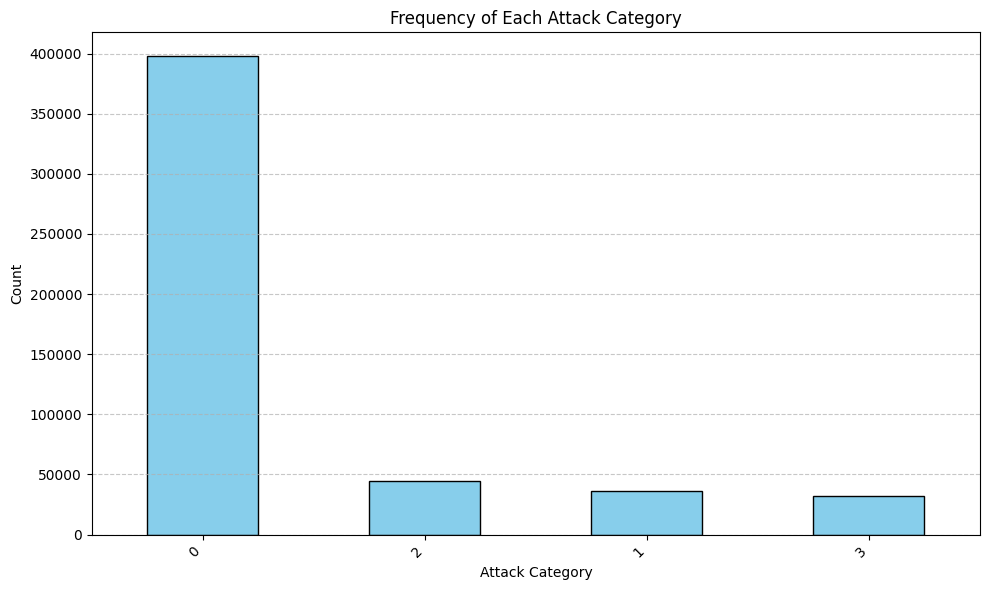

In [ ]:

# Step 3: Display the number of unique labels in 'Attack Category'
unique_labels = df['Output'].unique()
print("Number of unique labels in 'Attack Category':", len(unique_labels))
print("Unique labels:", unique_labels)

# Step 4: Count frequency of each label and plot as bar chart
label_counts = df['Output'].value_counts()

# Plotting
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Frequency of Each Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


BALANCING THE DATASET

In [ ]:
import pandas as pd
from sklearn.utils import resample

# Load the dataset
file_path = 'GPS_Data_Simplified_2D_Feature_Map.csv'
df = pd.read_csv(file_path)

# Check class distribution
print("Class distribution before balancing:")
print(df['Output'].value_counts())

# Separate majority and minority classes
majority_class = df[df['Output'] == df['Output'].value_counts().idxmax()]
minority_class = df[df['Output'] == df['Output'].value_counts().idxmin()]

# Upsample minority class
minority_upsampled = resample(minority_class,
                              replace=True,       # sample with replacement
                              n_samples=len(majority_class), # match majority class count
                              random_state=42)    # reproducibility

# Combine the majority class with the upsampled minority class
df_balanced = pd.concat([majority_class, minority_upsampled])

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Save to new CSV
balanced_file_path = 'GPS_Data_Simplified_2D_Feature_Map_Balanced.csv'
df_balanced.to_csv(balanced_file_path, index=False)

print(f"Balanced dataset saved to {balanced_file_path}")


Class distribution before balancing:
Output
0    397825
2     44232
1     36458
3     32015
Name: count, dtype: int64
Balanced dataset saved to GPS_Data_Simplified_2D_Feature_Map_Balanced.csv


VIEWING THE BALANCED DATASET

In [ ]:
# data needs not to be downloaded separately
df=pd.read_csv('/content/drive/MyDrive/ICTC 2025/GPS_Data_Simplified_2D_Feature_Map_Balanced.csv')
df.head()

,PRN,DO,PD,RX,TOW,CP,EC,LC,PC,PIP,PQP,TCD,CN0,Output
0,27,2753.094097,2323228.772,264064.04,264064.0323,-173235.61330,156803.69070,178206.38010,183008.02350,182986.04690,2836.072346,2918.464844,45.770573,3
1,9,1415.856906,2146707.484,263852.44,263852.4328,-45143.41960,99492.05469,87381.99219,110028.01560,106109.57030,-29101.949220,1384.526367,45.582912,0
2,8,4616.190785,4753638.489,263253.80,263253.7841,-269433.65660,96431.75000,110095.62500,121136.92970,57212.50781,-106774.929700,4799.493164,44.325287,0
3,3,-1862.844996,7705636.964,262943.34,262943.3143,88557.50414,62097.49609,61191.30859,65367.05078,49107.55859,-43142.773440,-2468.611084,40.807652,0
4,7,3840.722226,4281538.161,263260.56,263260.5457,-158052.20770,136645.64060,157983.67190,164041.29690,163014.51560,-18325.250000,3819.663086,47.509785,0


In [ ]:
df['Output'].unique()

array([3, 0])

Number of unique labels in 'Attack Category': 2
Unique labels: [3 0]


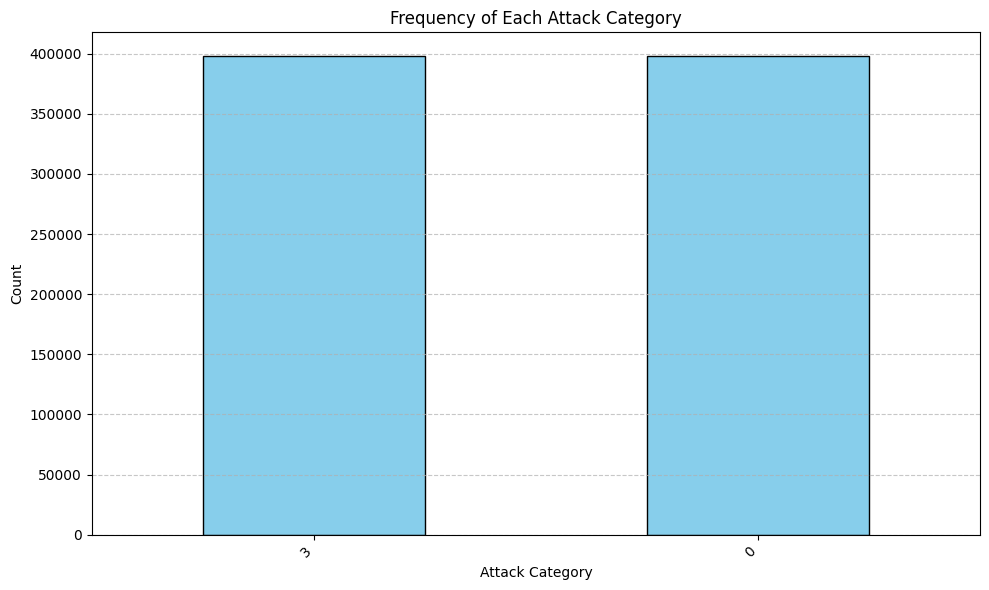

In [ ]:
# Step 3: Display the number of unique labels in 'Attack Category'
unique_labels = df['Output'].unique()
print("Number of unique labels in 'Attack Category':", len(unique_labels))
print("Unique labels:", unique_labels)

# Step 4: Count frequency of each label and plot as bar chart
label_counts = df['Output'].value_counts()

# Plotting
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Frequency of Each Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This result is bad. Hence, the oversampling method is not good. We try another method of balancing the dataset: RESAMPLING

In [ ]:
import pandas as pd
from sklearn.utils import resample

# Load dataset
file_path = 'GPS_Data_Simplified_2D_Feature_Map.csv'
df = pd.read_csv(file_path)

# Check class distribution before balancing
print("Class distribution before balancing:")
print(df['Output'].value_counts())

# Find the maximum class count
max_count = df['Output'].value_counts().max()

# Create a list to store balanced class dataframes
balanced_classes = []

# Resample each class to match the maximum count
for cls in df['Output'].unique():
    class_df = df[df['Output'] == cls]
    class_upsampled = resample(class_df,
                               replace=True,           # sample with replacement
                               n_samples=max_count,    # match the max class count
                               random_state=42)        # reproducibility
    balanced_classes.append(class_upsampled)

# Combine balanced classes into one dataframe
df_balanced = pd.concat(balanced_classes)

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the balanced dataset
balanced_file_path = 'GPS_Data_Simplified_2D_Feature_Map_Resample_Balanced.csv'
df_balanced.to_csv(balanced_file_path, index=False)

print(f"Balanced dataset saved as: {balanced_file_path}")
print("Class distribution after balancing:")
print(df_balanced['Output'].value_counts())


Class distribution before balancing:
Output
0    397825
2     44232
1     36458
3     32015
Name: count, dtype: int64
Balanced dataset saved as: GPS_Data_Simplified_2D_Feature_Map_Resample_Balanced.csv
Class distribution after balancing:
Output
0    397825
2    397825
3    397825
1    397825
Name: count, dtype: int64


VIEWING THE BALANCED DATASET (RESAMPLE METHOD)

In [ ]:
# data needs not to be downloaded separately
df=pd.read_csv('/content/drive/MyDrive/ICTC 2025/GPS_Data_Simplified_2D_Feature_Map_Resample_Balanced.csv')
df.head()

,PRN,DO,PD,RX,TOW,CP,EC,LC,PC,PIP,PQP,TCD,CN0,Output
0,4,-358.362703,2.635298e+06,262811.76,262811.7512,37940.18180,93798.63281,80978.5000,97284.6250,95006.08594,20931.837890,-378.072479,43.532207,0
1,7,3670.694801,3.777253e+06,263861.44,263861.4274,-149588.99730,148942.98440,142701.2813,156745.8906,-155924.29690,16027.693360,3649.146484,47.555210,0
2,7,3923.295821,4.646386e+06,262761.58,262761.5645,-290755.50980,139546.43750,153337.6094,165216.7500,-165215.17190,722.829956,3836.279541,46.942593,0
3,2,2600.137627,8.094886e+05,491863.66,491863.6573,-294319.03960,139955.31000,127175.7300,153912.3000,149064.44000,38324.789000,2602.129600,46.544559,2
4,26,-1571.988186,-4.962996e+06,173928.02,173928.0366,48024.95685,124488.99220,112017.1250,123267.4609,120949.39840,23793.046880,-1585.420898,47.123325,2


In [ ]:
df['Output'].unique()

array([0, 2, 3, 1])

Number of unique labels in 'Attack Category': 4
Unique labels: [0 2 3 1]


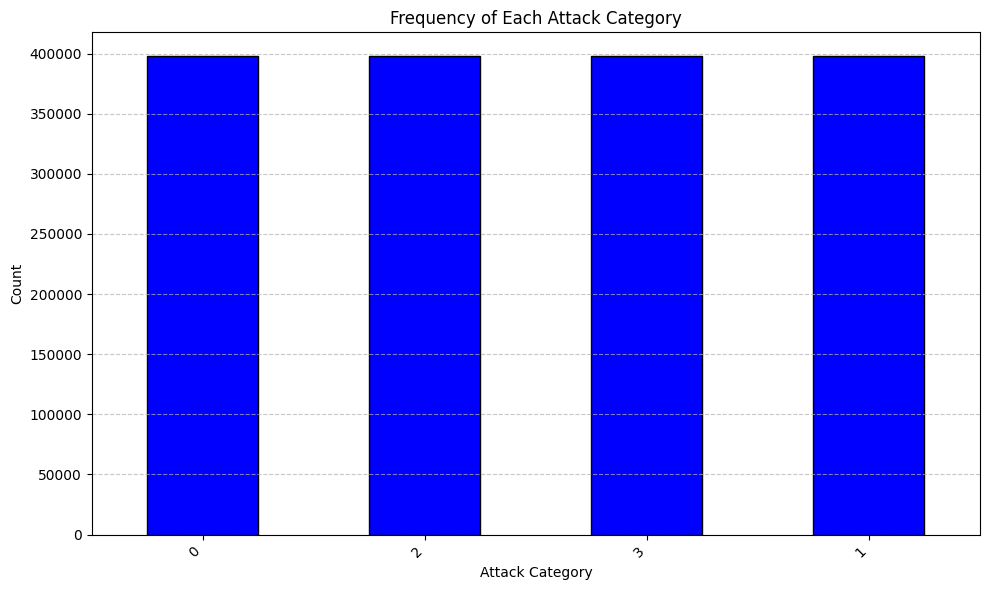

In [ ]:
# Step 3: Display the number of unique labels in 'Attack Category'
unique_labels = df['Output'].unique()
print("Number of unique labels in 'Attack Category':", len(unique_labels))
print("Unique labels:", unique_labels)

# Step 4: Count frequency of each label and plot as bar chart
label_counts = df['Output'].value_counts()

# Plotting
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color='blue', edgecolor='black')
plt.title("Frequency of Each Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This graph shows that all classes now have the same number of samples for better model prediction performance.

ANOTHER SAMPLING METHOD TO BALANCE DATASET (DOWN-SAMPLING)

Here’s the downsampling version of the balancing script, which makes each of the four classes match the smallest class size instead of the largest.
This avoids duplication but means you’ll lose some samples from the larger classes.

In [ ]:
import pandas as pd
from sklearn.utils import resample

# Load dataset
file_path = 'GPS_Data_Simplified_2D_Feature_Map.csv'
df = pd.read_csv(file_path)

# Check class distribution before balancing
print("Class distribution before balancing:")
print(df['Output'].value_counts())

# Find the minimum class count
min_count = df['Output'].value_counts().min()

# Create a list to store balanced class dataframes
balanced_classes = []

# Downsample each class to match the smallest class size
for cls in df['Output'].unique():
    class_df = df[df['Output'] == cls]
    class_downsampled = resample(class_df,
                                 replace=False,        # no replacement, just remove extras
                                 n_samples=min_count,  # match the min class count
                                 random_state=42)      # reproducibility
    balanced_classes.append(class_downsampled)

# Combine balanced classes into one dataframe
df_balanced = pd.concat(balanced_classes)

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the balanced dataset
balanced_file_path = 'GPS_Data_Simplified_2D_Feature_Map_Balanced_Downsampled.csv'
df_balanced.to_csv(balanced_file_path, index=False)

print(f"Balanced dataset saved as: {balanced_file_path}")
print("Class distribution after balancing:")
print(df_balanced['Output'].value_counts())


Class distribution before balancing:
Output
0    397825
2     44232
1     36458
3     32015
Name: count, dtype: int64
Balanced dataset saved as: GPS_Data_Simplified_2D_Feature_Map_Balanced_Downsampled.csv
Class distribution after balancing:
Output
1    32015
0    32015
2    32015
3    32015
Name: count, dtype: int64


VIEWING THE BALANCED DATASET (DOWNSAMLING METHOD)

In [ ]:
# data needs not to be downloaded separately
df=pd.read_csv('/content/drive/MyDrive/ICTC 2025/GPS_Data_Simplified_2D_Feature_Map_Balanced_Downsampled.csv')
df.head()

,PRN,DO,PD,RX,TOW,CP,EC,LC,PC,PIP,PQP,TCD,CN0,Output
0,30,4378.842624,6.598209e+06,263754.04,263754.0180,-876855.3251,62787.59766,75093.45313,78873.95313,78763.62500,-4170.415527,4344.137695,44.272228,1
1,7,3653.245012,3.762618e+06,263882.48,263882.4674,-226483.8693,125480.89060,119988.29690,134774.68750,-133913.21880,-15214.051760,3653.729004,46.297832,0
2,25,4652.252406,2.704103e+07,491989.02,491988.9298,-882861.0383,105283.66000,93872.25800,109609.70000,109055.96000,-11003.810000,4651.226600,40.016914,2
3,9,3325.109823,-2.542944e+06,173698.00,173698.0085,-251841.2380,68311.55469,75066.82031,75408.41406,72796.57813,-19674.542970,3314.563232,39.005234,2
4,8,4794.177531,5.147614e+06,262813.70,262813.6828,-282901.9511,101275.50780,101681.19530,121329.32030,118396.71090,26514.583980,4779.044922,42.022518,0


In [ ]:
df['Output'].unique()

array([1, 0, 2, 3])

Number of unique labels in 'Attack Category': 4
Unique labels: [1 0 2 3]


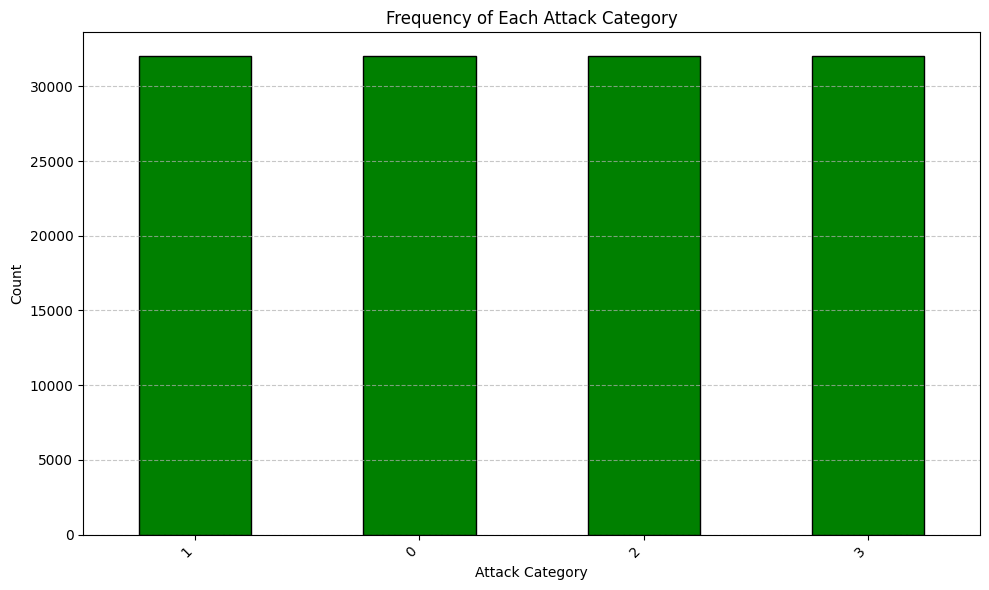

In [ ]:
# Step 3: Display the number of unique labels in 'Attack Category'
unique_labels = df['Output'].unique()
print("Number of unique labels in 'Attack Category':", len(unique_labels))
print("Unique labels:", unique_labels)

# Step 4: Count frequency of each label and plot as bar chart
label_counts = df['Output'].value_counts()

# Plotting
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color='green', edgecolor='black')
plt.title("Frequency of Each Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

OVERSAMPLING METHOD (SMOTE)

Here’s a hybrid SMOTE-based approach that balances your dataset by generating synthetic samples for the minority classes instead of simply duplicating them.
This helps maintain dataset size while improving class diversity.

Why SMOTE is Different
Instead of duplicating existing rows (upsampling) or removing rows (downsampling),
SMOTE interpolates between existing minority samples to create new synthetic points.

This keeps the dataset diverse and helps machine learning models generalize better.

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE

# Load dataset
file_path = 'GPS_Data_Simplified_2D_Feature_Map.csv'
df = pd.read_csv(file_path)

# Check original class distribution
print("Class distribution before balancing:")
print(df['Output'].value_counts())

# Separate features and target
X = df.drop(columns=['Output'])
y = df['Output']

# Apply SMOTE (Synthetic Minority Oversampling Technique)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Combine balanced features and target into a DataFrame
df_balanced = pd.DataFrame(X_resampled, columns=X.columns)
df_balanced['Output'] = y_resampled

# Check class distribution after balancing
print("\nClass distribution after balancing:")
print(df_balanced['Output'].value_counts())

# Save balanced dataset
balanced_file_path = 'GPS_Data_Simplified_2D_Feature_Map_Balanced_SMOTE.csv'
df_balanced.to_csv(balanced_file_path, index=False)

print(f"\nBalanced dataset saved as: {balanced_file_path}")


Class distribution before balancing:
Output
0    397825
2     44232
1     36458
3     32015
Name: count, dtype: int64

Class distribution after balancing:
Output
0    397825
1    397825
2    397825
3    397825
Name: count, dtype: int64

Balanced dataset saved as: GPS_Data_Simplified_2D_Feature_Map_Balanced_SMOTE.csv


VIEWING THE BALANCED DATASET (SMOTE METHOD)

In [ ]:
# data needs not to be downloaded separately
df=pd.read_csv('/content/drive/MyDrive/ICTC 2025/GPS_Data_Simplified_2D_Feature_Map_Balanced_SMOTE.csv')
df.head()

,PRN,DO,PD,RX,TOW,CP,EC,LC,PC,PIP,PQP,TCD,CN0,Output
0,6,1160.671408,-238359.5433,491568.00,491568.0008,-24660.26329,163521.78,170008.81,179294.97,178420.33,-17688.17800,1158.4806,49.412529,0
1,6,1157.827808,-238363.9212,491568.02,491568.0208,-24683.46852,158277.05,160253.09,182106.11,182106.05,158.33333,1160.7948,49.452686,0
2,6,1161.135932,-238368.6386,491568.04,491568.0408,-24706.68736,184442.36,193125.89,208228.02,-205198.30,35391.59000,1157.6909,49.480145,0
3,6,1161.156617,-238373.3918,491568.06,491568.0608,-24729.92004,159812.45,169960.55,187550.72,187543.00,-1701.94400,1161.1343,49.433769,0
4,6,1160.690893,-238378.1271,491568.08,491568.0808,-24753.15400,183557.66,191912.58,208403.50,208330.05,-5532.89990,1161.1759,49.391670,0


In [ ]:
df['Output'].unique()

array([0, 1, 2, 3])

Number of unique labels in 'Attack Category': 4
Unique labels: [0 1 2 3]


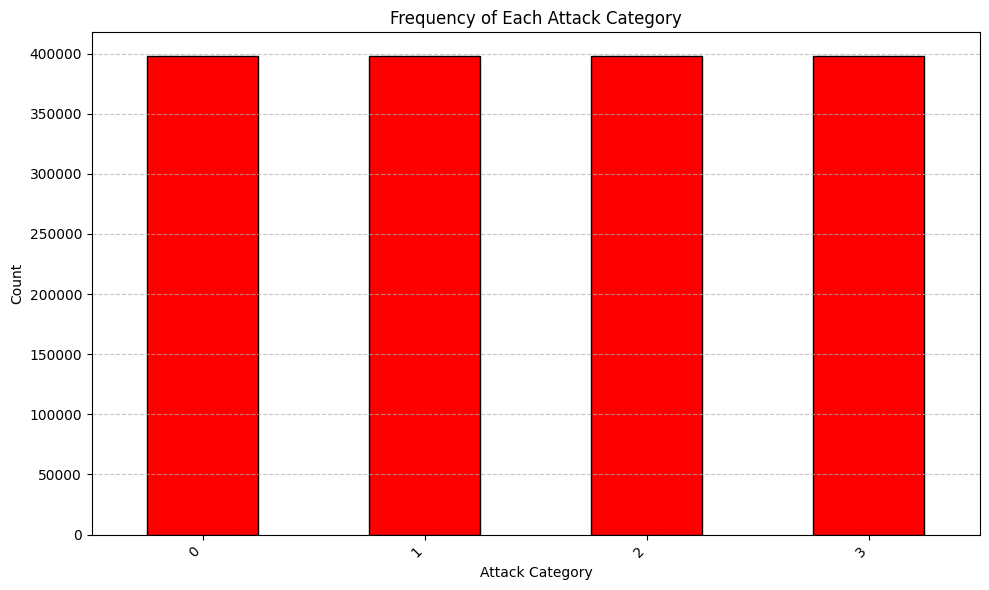

In [ ]:
# Step 3: Display the number of unique labels in 'Attack Category'
unique_labels = df['Output'].unique()
print("Number of unique labels in 'Attack Category':", len(unique_labels))
print("Unique labels:", unique_labels)

# Step 4: Count frequency of each label and plot as bar chart
label_counts = df['Output'].value_counts()

# Plotting
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color='red', edgecolor='black')
plt.title("Frequency of Each Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

TUNED SMOTE (To avoid Overfitting)

Here’s the tuned SMOTE version where you can balance your four classes to a specific ratio instead of making them perfectly equal.
This can help avoid overfitting while still reducing class imbalance.

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE

# Load dataset
file_path = 'GPS_Data_Simplified_2D_Feature_Map.csv'
df = pd.read_csv(file_path)

# Check original class distribution
print("Class distribution before balancing:")
print(df['Output'].value_counts())

# Separate features and target
X = df.drop(columns=['Output'])
y = df['Output']

# Set a balancing strategy: target 80% of the largest class size
max_class_size = y.value_counts().max()
target_size = int(max_class_size * 0.8)  # 80% of largest class

# Define a dictionary for SMOTE sampling strategy
# This keeps large classes unchanged, and up-samples small classes up to target_size
sampling_strategy = {cls: target_size if count < target_size else count
                     for cls, count in y.value_counts().items()}

print("\nSampling strategy for SMOTE:", sampling_strategy)

# Apply SMOTE with custom strategy
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Combine into balanced DataFrame
df_balanced = pd.DataFrame(X_resampled, columns=X.columns)
df_balanced['Output'] = y_resampled

# Check new distribution
print("\nClass distribution after partial balancing:")
print(df_balanced['Output'].value_counts())

# Save new balanced dataset
balanced_file_path = 'GPS_Data_Simplified_2D_Feature_Map_Balanced_SMOTE_Partial.csv'
df_balanced.to_csv(balanced_file_path, index=False)

print(f"\nBalanced dataset saved as: {balanced_file_path}")


Class distribution before balancing:
Output
0    397825
2     44232
1     36458
3     32015
Name: count, dtype: int64

Sampling strategy for SMOTE: {0: 397825, 2: 318260, 1: 318260, 3: 318260}

Class distribution after partial balancing:
Output
0    397825
1    318260
2    318260
3    318260
Name: count, dtype: int64

Balanced dataset saved as: GPS_Data_Simplified_2D_Feature_Map_Balanced_SMOTE_Partial.csv


VIEWING THE BALANCED DATASET ( TUNED SMOTE METHOD)
How this differs from normal SMOTE
Normal SMOTE: Makes all classes the same size.

This tuned SMOTE:

Leaves large classes untouched.

Only boosts smaller classes to 80% of the largest class size.

Reduces risk of overfitting by not oversampling too aggressively.

In [ ]:
# data needs not to be downloaded separately
df=pd.read_csv('/content/drive/MyDrive/ICTC 2025/GPS_Data_Simplified_2D_Feature_Map_Balanced_SMOTE_Partial.csv')
df.head()

,PRN,DO,PD,RX,TOW,CP,EC,LC,PC,PIP,PQP,TCD,CN0,Output
0,6,1160.671408,-238359.5433,491568.00,491568.0008,-24660.26329,163521.78,170008.81,179294.97,178420.33,-17688.17800,1158.4806,49.412529,0
1,6,1157.827808,-238363.9212,491568.02,491568.0208,-24683.46852,158277.05,160253.09,182106.11,182106.05,158.33333,1160.7948,49.452686,0
2,6,1161.135932,-238368.6386,491568.04,491568.0408,-24706.68736,184442.36,193125.89,208228.02,-205198.30,35391.59000,1157.6909,49.480145,0
3,6,1161.156617,-238373.3918,491568.06,491568.0608,-24729.92004,159812.45,169960.55,187550.72,187543.00,-1701.94400,1161.1343,49.433769,0
4,6,1160.690893,-238378.1271,491568.08,491568.0808,-24753.15400,183557.66,191912.58,208403.50,208330.05,-5532.89990,1161.1759,49.391670,0


In [ ]:
df['Output'].unique()

array([0, 1, 2, 3])

Number of unique labels in 'Attack Category': 4
Unique labels: [0 1 2 3]


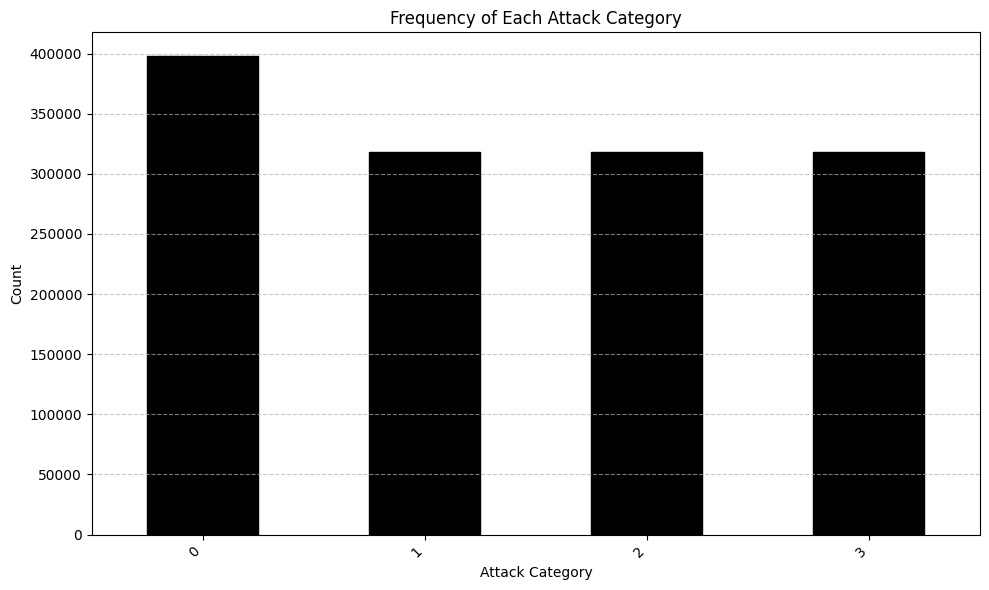

In [ ]:
# Step 3: Display the number of unique labels in 'Attack Category'
unique_labels = df['Output'].unique()
print("Number of unique labels in 'Attack Category':", len(unique_labels))
print("Unique labels:", unique_labels)

# Step 4: Count frequency of each label and plot as bar chart
label_counts = df['Output'].value_counts()

# Plotting
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color='black', edgecolor='black')
plt.title("Frequency of Each Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

ACI-IoT Dataset EDA

In [4]:
import os

# Define the path to your folder (modify as needed)
folder_path = "/content/drive/MyDrive/conquest-milcom"

# Change to the target directory
os.chdir(folder_path)

# Verify the current working directory
print("Current Directory:", os.getcwd())

# List files in the directory
print("Files in Directory:", os.listdir())

Current Directory: /content/drive/MyDrive/conquest-milcom
Files in Directory: ['ACI-IoT-2023-Payload.csv', 'ACI-IoT-2023.csv', 'ACI-IOT-Analysis.ipynb', 'Conquest2_newton_hessian.ipynb', 'Conquest2-sgd.ipynb', 'Conquest-lstm.ipynb', 'Conquest-context-lstm-adam.ipynb', 'Copy of XAI-Context-lstm-sgd.ipynb', 'Another-Script for Conquest.ipynb', 'New-Script for Conquest.ipynb', 'Conquest2_adam.ipynb', 'Letsdoit.ipynb', 'Conquest-no-context-lstm-adam.ipynb', 'Conquest-no-context-lstm-SGD.ipynb', 'XAI-Context-lstm-adam.ipynb', 'ADAM-CONTEXT-LSTM.ipynb', 'ADAM-Conquest-Context-Aware-lstm.ipynb', 'SGD_Conquest_Context_Aware_lstm.ipynb', 'EDA-new.ipynb']


In [5]:
pip install pandas numpy scikit-learn tensorflow openpyxl matplotlib seaborn


In [6]:
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, confusion_matrix, roc_auc_score, roc_curve
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [7]:
# data needs not to be downloaded separately
df=pd.read_csv('/content/drive/MyDrive/conquest-milcom/ACI-IoT-2023.csv')
df.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Connection Type
0,192.168.1.7-54.230.163.60-33344-443-6,192.168.1.7,33344,54.230.163.60,443,6,2023-01-11 09:43:40,379933,11,11,...,0.0,0.0,0.0,0.0,1.698846e+15,0.000000e+00,1.698846e+15,1.698846e+15,Benign,wired
1,192.168.3.6-91.189.91.48-36754-80-6,192.168.3.6,36754,91.189.91.48,80,6,2023-01-11 09:43:51,205637,3,3,...,0.0,0.0,0.0,0.0,1.698846e+15,0.000000e+00,1.698846e+15,1.698846e+15,Benign,wired
2,192.168.3.6-91.189.91.48-36754-80-6,192.168.3.6,36754,91.189.91.48,80,6,2023-01-11 09:43:51,0,2,0,...,0.0,0.0,0.0,0.0,1.698846e+15,0.000000e+00,1.698846e+15,1.698846e+15,Benign,wired
3,192.168.1.9-192.168.1.1-8080-40426-6,192.168.1.9,8080,192.168.1.1,40426,6,2023-01-11 09:43:49,5030379,1,2,...,0.0,0.0,0.0,0.0,8.494231e+14,1.201266e+15,1.698846e+15,5.030379e+06,Benign,wired
4,192.168.1.20-35.232.111.17-40054-80-6,192.168.1.20,40054,35.232.111.17,80,6,2023-01-11 09:43:56,72278,3,4,...,0.0,0.0,0.0,0.0,1.698846e+15,0.000000e+00,1.698846e+15,1.698846e+15,Benign,wired


In [8]:
df.describe()

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1.231411e+06,1.231411e+06,1.231411e+06,1.231411e+06,1.231411e+06,1.231411e+06,1.231411e+06,1.231411e+06,1.231411e+06,1.231411e+06,...,1.231411e+06,1.231411e+06,1.231411e+06,1.231411e+06,1.231411e+06,1.231411e+06,1.231411e+06,1.231411e+06,1.231411e+06,1.231411e+06
mean,3.680030e+04,1.540297e+04,6.433792e+00,5.236489e+06,5.456022e+00,5.439780e+00,4.998453e+03,2.078230e+04,1.060881e+02,1.164441e+01,...,1.863420e+00,1.819248e+01,1.102516e+05,3.884923e+04,1.499667e+05,7.955381e+04,1.511454e+15,2.308549e+14,1.698770e+15,1.354338e+15
std,2.331748e+04,2.044498e+04,4.919235e+00,1.188271e+07,1.819997e+02,2.185122e+02,4.582882e+05,1.237793e+06,8.296534e+02,4.859908e+01,...,7.790255e+01,1.141942e+01,1.088650e+06,4.855556e+05,1.365073e+06,9.600365e+05,3.787794e+14,4.621922e+14,1.096118e+11,6.829724e+14
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.415706e+14,0.000000e+00,1.698671e+15,5.000001e+06
25%,5.353000e+03,5.300000e+01,6.000000e+00,3.357000e+03,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.698672e+15,0.000000e+00,1.698683e+15,1.698672e+15
50%,4.814600e+04,3.017000e+03,6.000000e+00,6.631000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.698683e+15,0.000000e+00,1.698690e+15,1.698683e+15
75%,5.529500e+04,3.096650e+04,6.000000e+00,3.117183e+06,2.000000e+00,1.000000e+00,2.400000e+01,0.000000e+00,1.100000e+01,2.000000e+00,...,0.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.698766e+15,0.000000e+00,1.698847e+15,1.698766e+15
max,6.553500e+04,6.553500e+04,1.700000e+01,6.094632e+07,7.418000e+04,7.247000e+04,2.382375e+08,2.646032e+08,3.830400e+04,1.553300e+04,...,2.885900e+04,4.400000e+01,5.406848e+07,3.246857e+07,5.406848e+07,5.406848e+07,1.699037e+15,1.201401e+15,1.699037e+15,1.699037e+15


In [9]:
df['Label'].unique()

array(['Benign', 'ICMP Flood', 'Slowloris', 'SYN Flood', 'UDP Flood',
       'DNS Flood', 'Dictionary Attack', 'OS Scan', 'Port Scan',
       'Ping Sweep', 'Vulnerability Scan', 'ARP Spoofing'], dtype=object)

Number of unique labels in 'Attack Category': 12
Unique labels: ['Benign' 'ICMP Flood' 'Slowloris' 'SYN Flood' 'UDP Flood' 'DNS Flood'
 'Dictionary Attack' 'OS Scan' 'Port Scan' 'Ping Sweep'
 'Vulnerability Scan' 'ARP Spoofing']


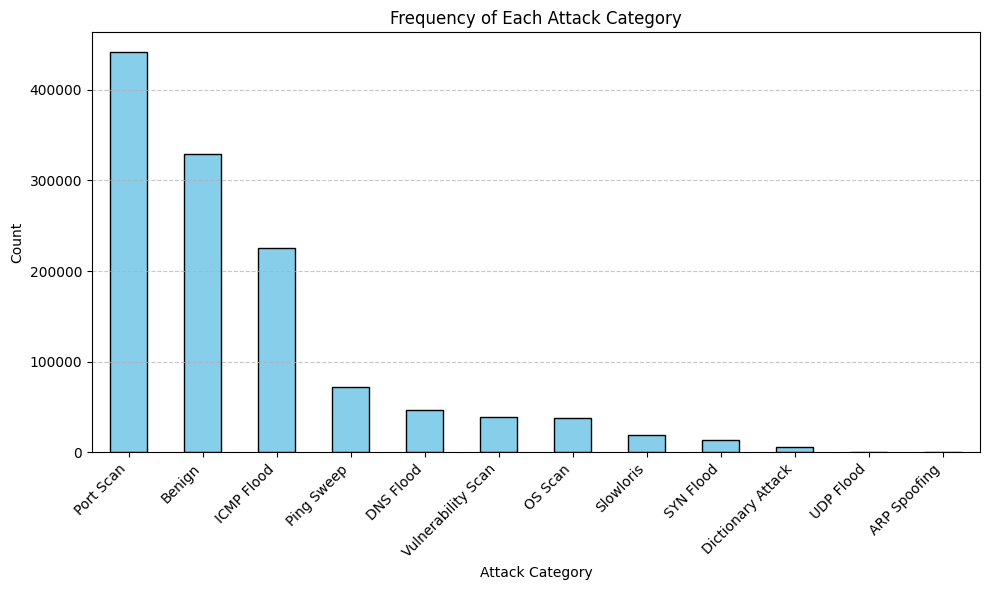

In [10]:

# Step 3: Display the number of unique labels in 'Attack Category'
unique_labels = df['Label'].unique()
print("Number of unique labels in 'Attack Category':", len(unique_labels))
print("Unique labels:", unique_labels)

# Step 4: Count frequency of each label and plot as bar chart
label_counts = df['Label'].value_counts()

# Plotting
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Frequency of Each Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
import numpy as np

# Load dataset
file_path = 'ACI-IoT-2023.csv'
df = pd.read_csv(file_path)

# Check original class distribution
print("Class distribution before balancing:")
print(df['Label'].value_counts())

# Separate features and target
# Exclude non-numeric columns
non_numeric_cols = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label', 'Connection Type']
X = df.drop(columns=non_numeric_cols)
y = df['Label']

# Replace infinite values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Handle missing values by filling with the mean of each column
X = X.fillna(X.mean())


# Set a balancing strategy: target 80% of the largest class size
max_class_size = y.value_counts().max()
target_size = int(max_class_size * 0.8)  # 80% of largest class

# Define a dictionary for SMOTE sampling strategy
# This keeps large classes unchanged, and up-samples small classes up to target_size
sampling_strategy = {cls: target_size if count < target_size else count
                     for cls, count in y.value_counts().items()}

print("\nSampling strategy for SMOTE:", sampling_strategy)

# Apply SMOTE with custom strategy
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Combine into balanced DataFrame
df_balanced = pd.DataFrame(X_resampled, columns=X.columns)
df_balanced['Label'] = y_resampled

# Check new distribution
print("\nClass distribution after partial balancing:")
print(df_balanced['Label'].value_counts())

# Save new balanced dataset
balanced_file_path = 'ACI-IoT-2023_Balanced_SMOTE_Partial.csv'
df_balanced.to_csv(balanced_file_path, index=False)

print(f"\nBalanced dataset saved as: {balanced_file_path}")

In [ ]:
# data needs not to be downloaded separately
df=pd.read_csv('/content/drive/MyDrive/ICTC 2025/GPS_Data_Simplified_2D_Feature_Map_Balanced_SMOTE_Partial.csv')
df.head()

,PRN,DO,PD,RX,TOW,CP,EC,LC,PC,PIP,PQP,TCD,CN0,Output
0,6,1160.671408,-238359.5433,491568.00,491568.0008,-24660.26329,163521.78,170008.81,179294.97,178420.33,-17688.17800,1158.4806,49.412529,0
1,6,1157.827808,-238363.9212,491568.02,491568.0208,-24683.46852,158277.05,160253.09,182106.11,182106.05,158.33333,1160.7948,49.452686,0
2,6,1161.135932,-238368.6386,491568.04,491568.0408,-24706.68736,184442.36,193125.89,208228.02,-205198.30,35391.59000,1157.6909,49.480145,0
3,6,1161.156617,-238373.3918,491568.06,491568.0608,-24729.92004,159812.45,169960.55,187550.72,187543.00,-1701.94400,1161.1343,49.433769,0
4,6,1160.690893,-238378.1271,491568.08,491568.0808,-24753.15400,183557.66,191912.58,208403.50,208330.05,-5532.89990,1161.1759,49.391670,0


In [ ]:
df['Output'].unique()

array([0, 1, 2, 3])

Number of unique labels in 'Attack Category': 4
Unique labels: [0 1 2 3]


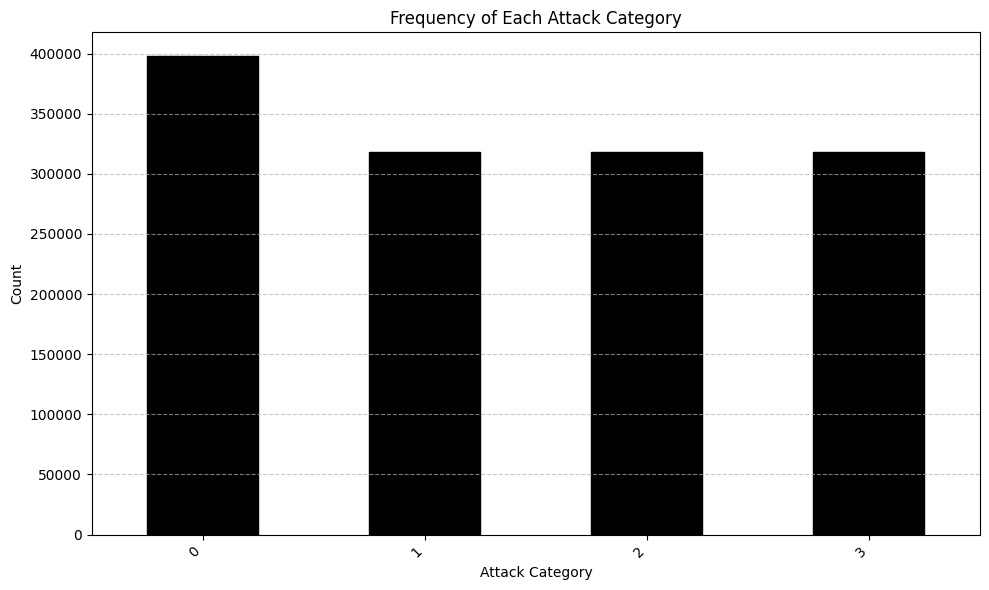

In [ ]:
# Step 3: Display the number of unique labels in 'Attack Category'
unique_labels = df['Output'].unique()
print("Number of unique labels in 'Attack Category':", len(unique_labels))
print("Unique labels:", unique_labels)

# Step 4: Count frequency of each label and plot as bar chart
label_counts = df['Output'].value_counts()

# Plotting
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color='black', edgecolor='black')
plt.title("Frequency of Each Attack Category")
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Values less than 12 or greater than 20: 6874
Values greater than 12 but less than 20: 8661


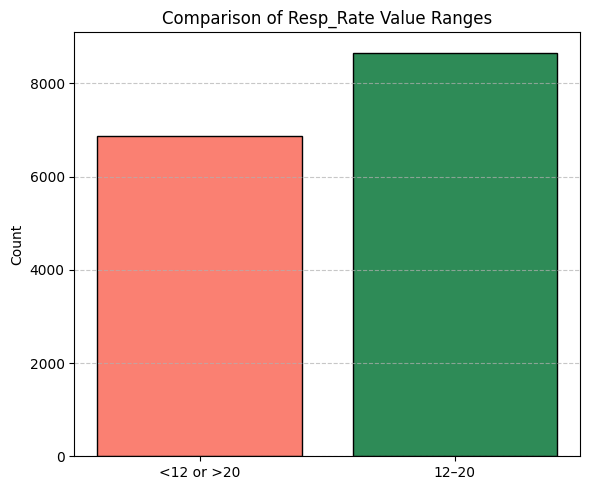

In [ ]:
#Checking the Resp Rate Column
# Ensure 'Resp_Rate' is numeric
df['Resp_Rate'] = pd.to_numeric(df['Resp_Rate'], errors='coerce')

# Filter and count the values
outside_range = df[(df['Resp_Rate'] < 12) | (df['Resp_Rate'] > 20)]
within_range = df[(df['Resp_Rate'] > 12) & (df['Resp_Rate'] < 20)]

outside_count = outside_range.shape[0]
within_count = within_range.shape[0]

print(f"Values less than 12 or greater than 20: {outside_count}")
print(f"Values greater than 12 but less than 20: {within_count}")

# Plotting the comparison
plt.figure(figsize=(6, 5))
plt.bar(['<12 or >20', '12–20'], [outside_count, within_count], color=['salmon', 'seagreen'], edgecolor='black')
plt.title("Comparison of Resp_Rate Value Ranges")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Python code that will display the comparison of the number of values that are between 95 and 100 vs the number that are less than 95 but greater than 100 in the column names "SpO2"

Values between 95 and 100 (inclusive): 16107
Values less than 95 or greater than 100: 211


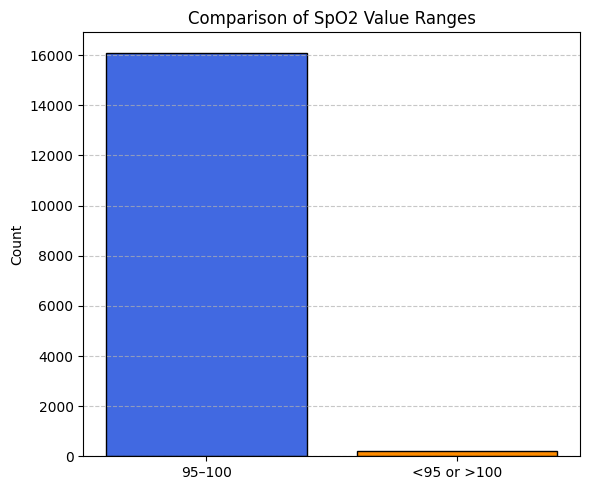

In [ ]:
# Ensure 'SpO2' is numeric
df['SpO2'] = pd.to_numeric(df['SpO2'], errors='coerce')

# Filter the groups
within_range = df[(df['SpO2'] >= 95) & (df['SpO2'] <= 100)]
outside_range = df[(df['SpO2'] < 95) | (df['SpO2'] > 100)]

# Count values
within_count = within_range.shape[0]
outside_count = outside_range.shape[0]

print(f"Values between 95 and 100 (inclusive): {within_count}")
print(f"Values less than 95 or greater than 100: {outside_count}")

# Plotting
plt.figure(figsize=(6, 5))
plt.bar(['95–100', '<95 or >100'], [within_count, outside_count], color=['royalblue', 'darkorange'], edgecolor='black')
plt.title("Comparison of SpO2 Value Ranges")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Write a Python code that will display the comparison of the number of values that are between 60 and 100 vs the number that are less than 60 but greater than 100 in the column names "Heart_rate"

Values between 60 and 100 (inclusive): 16044
Values less than 60 or greater than 100: 274


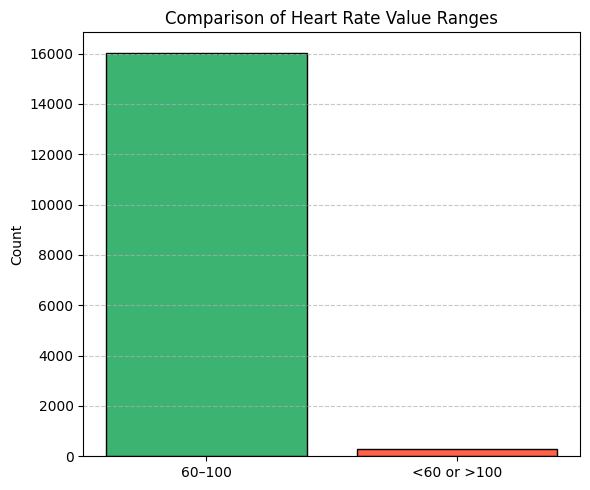

In [ ]:
# Ensure 'Heart_rate' is numeric
df['Heart_rate'] = pd.to_numeric(df['Heart_rate'], errors='coerce')

# Filter value ranges
within_range = df[(df['Heart_rate'] >= 60) & (df['Heart_rate'] <= 100)]
outside_range = df[(df['Heart_rate'] < 60) | (df['Heart_rate'] > 100)]

# Count values
within_count = within_range.shape[0]
outside_count = outside_range.shape[0]

print(f"Values between 60 and 100 (inclusive): {within_count}")
print(f"Values less than 60 or greater than 100: {outside_count}")

# Plotting
plt.figure(figsize=(6, 5))
plt.bar(['60–100', '<60 or >100'], [within_count, outside_count], color=['mediumseagreen', 'tomato'], edgecolor='black')
plt.title("Comparison of Heart Rate Value Ranges")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Prompt: Based on these analyses, it is evident that the dataset has imbalanced classes. Write a Python code that will balance the columns of the dataset such that: (a) the "Attack Category" column will have a balanced distribution of each unique class; (b) Also, the "SpO2" column will have  a balanced distribution with the condition of the number of values that are between 95 and 100 vs the number that are less than 95 but greater than 100 in the column names "SpO2"; (c) The "Heart_rate" column will have  a balanced distribution with the condition of the number of values that are between 60 and 100 vs the number that are less than 60 but greater than 100 in the column names "Heart_rate". Plot the graph to show the balanced dataset. Save the new balanced dataset as a new csv file.

To balance the dataset based on the following three criteria:
✅ Balance Goals:
Attack Category: Ensure equal number of samples for each class.

SpO2:

Class A: 95–100 (inclusive)

Class B: <95 or >100

Heart_rate:

Class A: 60–100 (inclusive)

Class B: <60 or >100

We'll use undersampling to balance each group by reducing all categories/groups to the minimum group size.

Here’s the full Python code to:

Load the dataset

Balance all three criteria

Visualize the result

Save the new balanced dataset to a CSV file

/tmp/ipython-input-26-163775690.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_attack = df.groupby('Attack Category').apply(lambda x: x.sample(min_class_size, random_state=42))


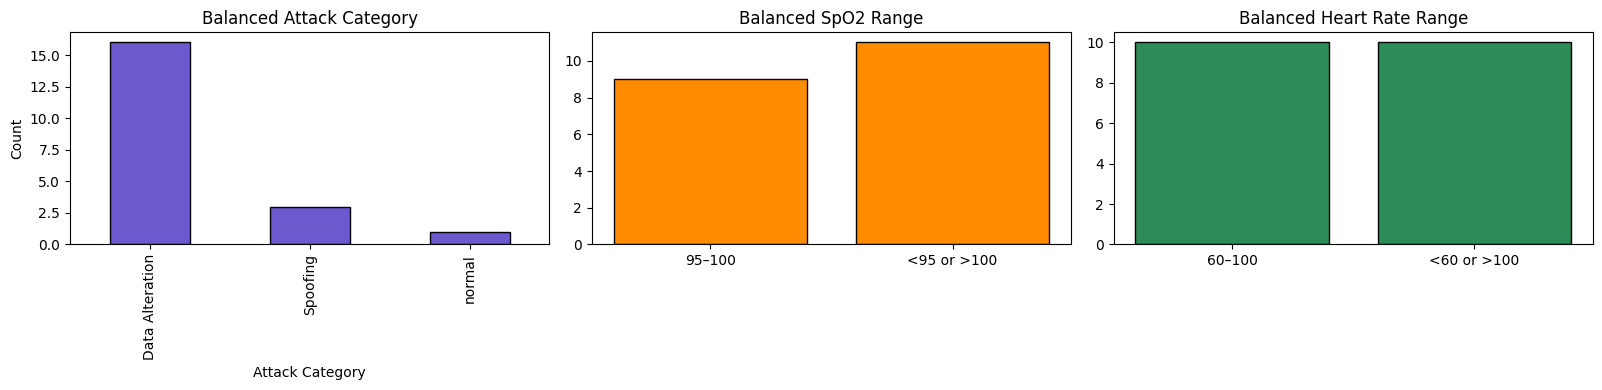

Balanced dataset saved to: /content/drive/MyDrive/chigozie/balanced_dataset.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample

# Ensure numeric columns
df['SpO2'] = pd.to_numeric(df['SpO2'], errors='coerce')
df['Heart_rate'] = pd.to_numeric(df['Heart_rate'], errors='coerce')

# (a) Balance Attack Category using undersampling
min_class_size = df['Attack Category'].value_counts().min()
balanced_attack = df.groupby('Attack Category').apply(lambda x: x.sample(min_class_size, random_state=42))
balanced_attack = balanced_attack.reset_index(drop=True)

# (b) Balance SpO2 between two conditions
sp_within = balanced_attack[(balanced_attack['SpO2'] >= 95) & (balanced_attack['SpO2'] <= 100)]
sp_outside = balanced_attack[(balanced_attack['SpO2'] < 95) | (balanced_attack['SpO2'] > 100)]
min_sp_size = min(len(sp_within), len(sp_outside))
balanced_sp = pd.concat([
    sp_within.sample(min_sp_size, random_state=42),
    sp_outside.sample(min_sp_size, random_state=42)
])

# (c) Balance Heart_rate between two conditions
hr_within = balanced_sp[(balanced_sp['Heart_rate'] >= 60) & (balanced_sp['Heart_rate'] <= 100)]
hr_outside = balanced_sp[(balanced_sp['Heart_rate'] < 60) | (balanced_sp['Heart_rate'] > 100)]
min_hr_size = min(len(hr_within), len(hr_outside))
final_balanced = pd.concat([
    hr_within.sample(min_hr_size, random_state=42),
    hr_outside.sample(min_hr_size, random_state=42)
])

# Reset index
final_balanced = final_balanced.reset_index(drop=True)

# (d) Plotting comparisons after balancing
plt.figure(figsize=(16, 4))

# 1. Attack Category
plt.subplot(1, 3, 1)
final_balanced['Attack Category'].value_counts().plot(kind='bar', color='slateblue', edgecolor='black')
plt.title("Balanced Attack Category")
plt.ylabel("Count")

# 2. SpO2 Range
plt.subplot(1, 3, 2)
spo2_labels = ['95–100', '<95 or >100']
spo2_counts = [
    ((final_balanced['SpO2'] >= 95) & (final_balanced['SpO2'] <= 100)).sum(),
    ((final_balanced['SpO2'] < 95) | (final_balanced['SpO2'] > 100)).sum()
]
plt.bar(spo2_labels, spo2_counts, color='darkorange', edgecolor='black')
plt.title("Balanced SpO2 Range")

# 3. Heart Rate Range
plt.subplot(1, 3, 3)
hr_labels = ['60–100', '<60 or >100']
hr_counts = [
    ((final_balanced['Heart_rate'] >= 60) & (final_balanced['Heart_rate'] <= 100)).sum(),
    ((final_balanced['Heart_rate'] < 60) | (final_balanced['Heart_rate'] > 100)).sum()
]
plt.bar(hr_labels, hr_counts, color='seagreen', edgecolor='black')
plt.title("Balanced Heart Rate Range")

plt.tight_layout()
plt.show()

# (e) Save the final balanced dataset
#output_path = '/mnt/data/balanced_dataset.csv'
output_path = '/content/drive/MyDrive/chigozie/balanced_dataset.csv'
final_balanced.to_csv(output_path, index=False)
print(f"Balanced dataset saved to: {output_path}")


Prompt: Based on these analyses, it is evident that the dataset has imbalanced classes. Write a Python code that will balance the columns of the dataset such that: (a) the "Attack Category" column will equal number for each unique class "Data Alteration", "normal", "Spoofing"; (b) Also, the "SpO2" column will have  a balanced distribution with the condition of the number of values that are between 95 and 100 vs the number that are less than 95 but greater than 100 in the column names "SpO2"; (c) The "Heart_rate" column will have  a balanced distribution with the condition of the number of values that are between 60 and 100 vs the number that are less than 60 but greater than 100 in the column names "Heart_rate". Plot the graph to show the balanced dataset. Save the new balanced dataset as a new csv file.

Does the following:
Balances the Attack Category column to have equal samples for:

"Data Alteration", "normal", and "Spoofing".

Balances the SpO2 column by undersampling the majority between:

Values 95–100 vs values <95 or >100.

Balances the Heart_rate column by undersampling between:

Values 60–100 vs values <60 or >100.

Plots bar charts showing balanced distributions.

Saves the balanced DataFrame as a new CSV file.

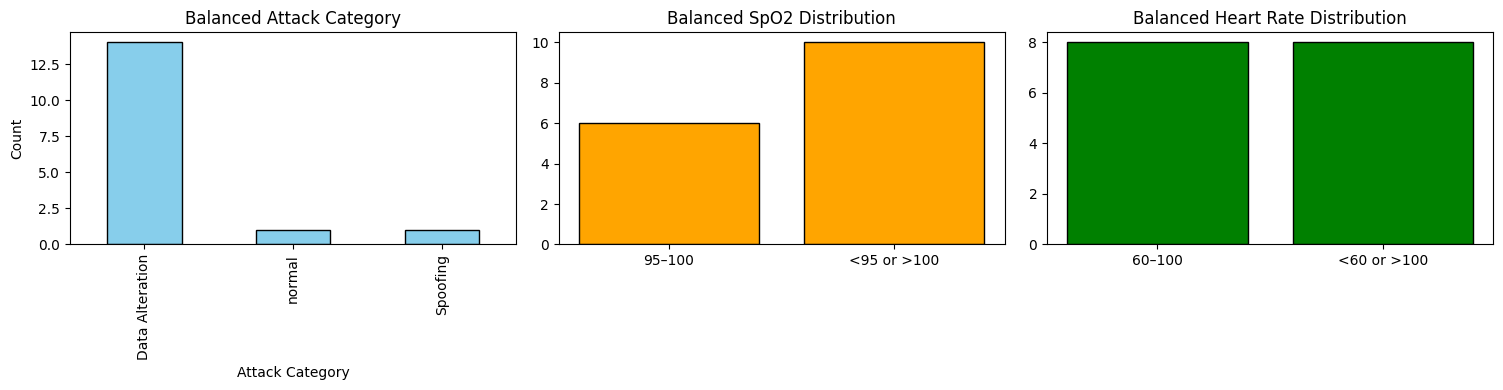

✅ Balanced dataset saved as 'balanced_wustl_dataset.csv'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Ensure numeric types
df['SpO2'] = pd.to_numeric(df['SpO2'], errors='coerce')
df['Heart_rate'] = pd.to_numeric(df['Heart_rate'], errors='coerce')

# --- Step 1: Balance Attack Category ---
target_classes = ['Data Alteration', 'normal', 'Spoofing']
filtered_df = df[df['Attack Category'].isin(target_classes)]

# Find min class count
min_count = filtered_df['Attack Category'].value_counts().min()

# Sample equal number of each class
balanced_attack_df = pd.concat([
    filtered_df[filtered_df['Attack Category'] == cat].sample(min_count, random_state=42)
    for cat in target_classes
])

# --- Step 2: Balance SpO2 Column ---
spo2_in = balanced_attack_df[(balanced_attack_df['SpO2'] >= 95) & (balanced_attack_df['SpO2'] <= 100)]
spo2_out = balanced_attack_df[(balanced_attack_df['SpO2'] < 95) | (balanced_attack_df['SpO2'] > 100)]

spo2_min = min(len(spo2_in), len(spo2_out))

balanced_spo2_df = pd.concat([
    spo2_in.sample(spo2_min, random_state=42),
    spo2_out.sample(spo2_min, random_state=42)
])

# --- Step 3: Balance Heart Rate Column ---
hr_in = balanced_spo2_df[(balanced_spo2_df['Heart_rate'] >= 60) & (balanced_spo2_df['Heart_rate'] <= 100)]
hr_out = balanced_spo2_df[(balanced_spo2_df['Heart_rate'] < 60) | (balanced_spo2_df['Heart_rate'] > 100)]

hr_min = min(len(hr_in), len(hr_out))

balanced_hr_df = pd.concat([
    hr_in.sample(hr_min, random_state=42),
    hr_out.sample(hr_min, random_state=42)
])

# Final balanced dataset
balanced_df = balanced_hr_df.reset_index(drop=True)

# --- Step 4: Plot distributions ---

plt.figure(figsize=(15, 4))

# Attack Category
plt.subplot(1, 3, 1)
balanced_df['Attack Category'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Balanced Attack Category")
plt.ylabel("Count")

# SpO2
plt.subplot(1, 3, 2)
spo2_labels = ['95–100', '<95 or >100']
spo2_counts = [
    ((balanced_df['SpO2'] >= 95) & (balanced_df['SpO2'] <= 100)).sum(),
    ((balanced_df['SpO2'] < 95) | (balanced_df['SpO2'] > 100)).sum()
]
plt.bar(spo2_labels, spo2_counts, color='orange', edgecolor='black')
plt.title("Balanced SpO2 Distribution")

# Heart_rate
plt.subplot(1, 3, 3)
hr_labels = ['60–100', '<60 or >100']
hr_counts = [
    ((balanced_df['Heart_rate'] >= 60) & (balanced_df['Heart_rate'] <= 100)).sum(),
    ((balanced_df['Heart_rate'] < 60) | (balanced_df['Heart_rate'] > 100)).sum()
]
plt.bar(hr_labels, hr_counts, color='green', edgecolor='black')
plt.title("Balanced Heart Rate Distribution")

plt.tight_layout()
plt.show()

# --- Step 5: Save balanced dataset ---
balanced_df.to_csv('/content/drive/MyDrive/chigozie/balanced_dataset2.csv', index=False)
print("✅ Balanced dataset saved as 'balanced_wustl_dataset.csv'")


USING OVERSAMPLING TECHNIQUE TO BALANCE THE DATSET as undersampling reduced the dataset volumne.
🎯 What this version does:
Balances "Attack Category" by oversampling to match the most frequent class.

Balances "SpO2" distribution:

Values 95–100 vs values <95 or >100.

Balances "Heart_rate" distribution:

Values 60–100 vs values <60 or >100.

Plots bar charts to show the balanced result.

Saves the balanced dataset as a CSV file.


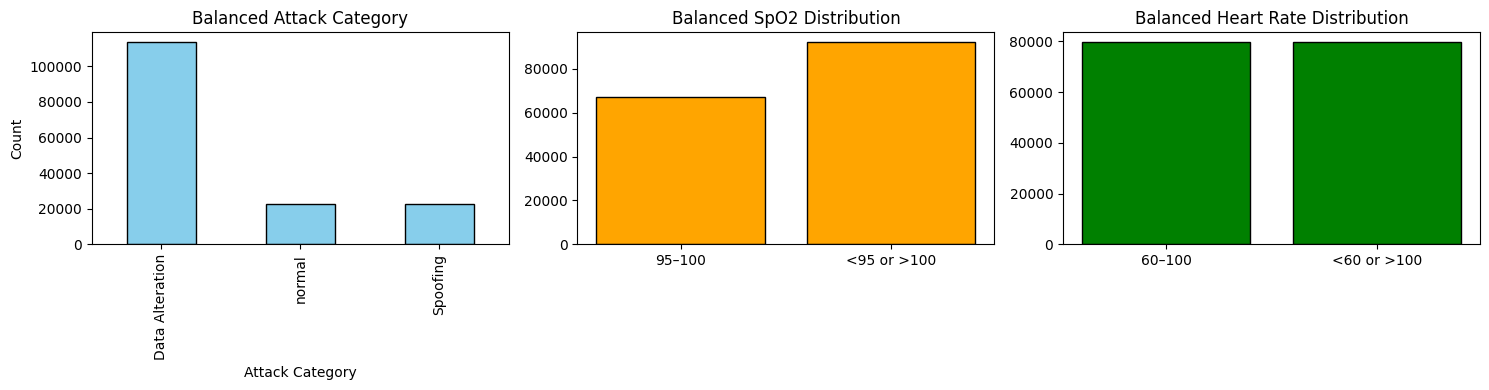

✅ Oversampled balanced dataset saved as 'oversampled_balanced_wustl_dataset.csv'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample


# Ensure numeric
df['SpO2'] = pd.to_numeric(df['SpO2'], errors='coerce')
df['Heart_rate'] = pd.to_numeric(df['Heart_rate'], errors='coerce')

# --- Step 1: Oversample Attack Category ---
target_classes = ['Data Alteration', 'normal', 'Spoofing']
df_attack = df[df['Attack Category'].isin(target_classes)]

# Get the size of the largest class
max_class_size = df_attack['Attack Category'].value_counts().max()

# Oversample each class to match the largest
oversampled_classes = []
for cls in target_classes:
    subset = df_attack[df_attack['Attack Category'] == cls]
    oversampled = resample(subset, replace=True, n_samples=max_class_size, random_state=42)
    oversampled_classes.append(oversampled)

balanced_attack_df = pd.concat(oversampled_classes)

# --- Step 2: Oversample SpO2 ranges ---
spo2_in = balanced_attack_df[(balanced_attack_df['SpO2'] >= 95) & (balanced_attack_df['SpO2'] <= 100)]
spo2_out = balanced_attack_df[(balanced_attack_df['SpO2'] < 95) | (balanced_attack_df['SpO2'] > 100)]

spo2_max = max(len(spo2_in), len(spo2_out))

spo2_in_oversampled = resample(spo2_in, replace=True, n_samples=spo2_max, random_state=42)
spo2_out_oversampled = resample(spo2_out, replace=True, n_samples=spo2_max, random_state=42)

balanced_spo2_df = pd.concat([spo2_in_oversampled, spo2_out_oversampled])

# --- Step 3: Oversample Heart_rate ranges ---
hr_in = balanced_spo2_df[(balanced_spo2_df['Heart_rate'] >= 60) & (balanced_spo2_df['Heart_rate'] <= 100)]
hr_out = balanced_spo2_df[(balanced_spo2_df['Heart_rate'] < 60) | (balanced_spo2_df['Heart_rate'] > 100)]

hr_max = max(len(hr_in), len(hr_out))

hr_in_oversampled = resample(hr_in, replace=True, n_samples=hr_max, random_state=42)
hr_out_oversampled = resample(hr_out, replace=True, n_samples=hr_max, random_state=42)

balanced_hr_df = pd.concat([hr_in_oversampled, hr_out_oversampled]).reset_index(drop=True)

# --- Step 4: Plot Distributions ---

plt.figure(figsize=(15, 4))

# Attack Category
plt.subplot(1, 3, 1)
balanced_hr_df['Attack Category'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Balanced Attack Category")
plt.ylabel("Count")

# SpO2
plt.subplot(1, 3, 2)
spo2_labels = ['95–100', '<95 or >100']
spo2_counts = [
    ((balanced_hr_df['SpO2'] >= 95) & (balanced_hr_df['SpO2'] <= 100)).sum(),
    ((balanced_hr_df['SpO2'] < 95) | (balanced_hr_df['SpO2'] > 100)).sum()
]
plt.bar(spo2_labels, spo2_counts, color='orange', edgecolor='black')
plt.title("Balanced SpO2 Distribution")

# Heart Rate
plt.subplot(1, 3, 3)
hr_labels = ['60–100', '<60 or >100']
hr_counts = [
    ((balanced_hr_df['Heart_rate'] >= 60) & (balanced_hr_df['Heart_rate'] <= 100)).sum(),
    ((balanced_hr_df['Heart_rate'] < 60) | (balanced_hr_df['Heart_rate'] > 100)).sum()
]
plt.bar(hr_labels, hr_counts, color='green', edgecolor='black')
plt.title("Balanced Heart Rate Distribution")

plt.tight_layout()
plt.show()

# --- Step 5: Save the final balanced dataset ---
balanced_hr_df.to_csv('/content/drive/MyDrive/chigozie/oversampled_balanced_dataset.csv', index=False)
print("✅ Oversampled balanced dataset saved as 'oversampled_balanced_wustl_dataset.csv'")


To balance the dataset using SMOTE (Synthetic Minority Oversampling Technique), we need to follow these steps:
✅ Objective Breakdown:
Balance "Attack Category" – using label encoding + SMOTE for categorical class balancing.

Balance "SpO2" – create a binary label:

1 if 95–100

0 otherwise, and balance it via SMOTE.

Balance "Heart_rate" – create a binary label:

1 if 60–100

0 otherwise, and balance it via SMOTE.

Plot distributions after balancing.

Save the balanced dataset.

⚠️ SMOTE caveats:
SMOTE works only with numeric features, so categorical ones must be encoded or dropped temporarily.

We'll use imblearn for SMOTE.



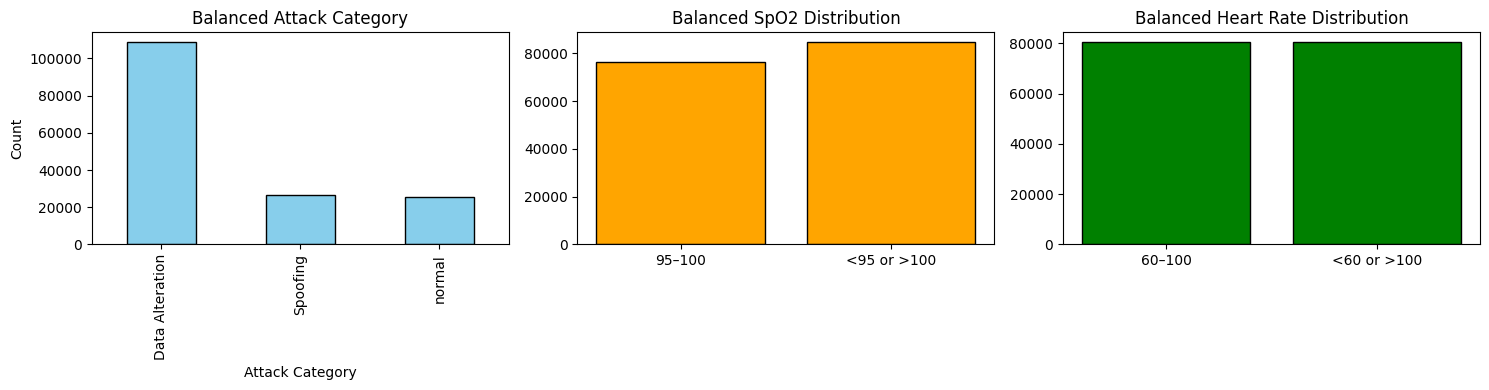

✅ SMOTE-balanced dataset saved as '/content/drive/MyDrive/chigozie/smote_balanced_wustl_dataset.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# Step 1: Load and preprocess the dataset

file_path = '/content/drive/MyDrive/chigozie/wustl-ehms-2020_with_attacks_categories.csv'
df = pd.read_csv(file_path)

# Keep only relevant classes in "Attack Category"
target_classes = ['Data Alteration', 'normal', 'Spoofing']
df_filtered = df[df['Attack Category'].isin(target_classes)].copy()

# Ensure numeric columns and handle NaNs
df_filtered['SpO2'] = pd.to_numeric(df_filtered['SpO2'], errors='coerce')
df_filtered['Heart_rate'] = pd.to_numeric(df_filtered['Heart_rate'], errors='coerce')
df_filtered.dropna(subset=['SpO2', 'Heart_rate'], inplace=True)

# Step 2: Prepare features and labels for SMOTE (Attack Category)
feature_cols = ['SpO2', 'Heart_rate'] # Using only these features for SMOTE
X = df_filtered[feature_cols]
y_attack = df_filtered['Attack Category']

# Step 3: Label encode the Attack Category for SMOTE
le = LabelEncoder()
y_attack_encoded = le.fit_transform(y_attack)

# Step 4: Apply SMOTE to balance Attack Category
sm = SMOTE(random_state=42)
X_resampled, y_attack_resampled_encoded = sm.fit_resample(X, y_attack_encoded)

# Convert the resampled data back to a DataFrame
balanced_attack_df = pd.DataFrame(X_resampled, columns=feature_cols)
balanced_attack_df['Attack Category'] = le.inverse_transform(y_attack_resampled_encoded)

# Step 5: Balance SpO2 condition on the balanced_attack_df
spo2_in = balanced_attack_df[(balanced_attack_df['SpO2'] >= 95) & (balanced_attack_df['SpO2'] <= 100)]
spo2_out = balanced_attack_df[(balanced_attack_df['SpO2'] < 95) | (balanced_attack_df['SpO2'] > 100)]

# Determine the target size for SpO2 balancing (using the size of the majority class after attack balancing)
spo2_target_size = max(len(spo2_in), len(spo2_out))

# Resample the minority class(es) for SpO2
if len(spo2_in) < spo2_target_size:
    spo2_in_resampled = resample(spo2_in, replace=True, n_samples=spo2_target_size, random_state=42)
else:
    spo2_in_resampled = spo2_in

if len(spo2_out) < spo2_target_size:
    spo2_out_resampled = resample(spo2_out, replace=True, n_samples=spo2_target_size, random_state=42)
else:
    spo2_out_resampled = spo2_out


balanced_spo2_df = pd.concat([spo2_in_resampled, spo2_out_resampled]).reset_index(drop=True)


# Step 6: Balance Heart_rate condition on the balanced_spo2_df
hr_in = balanced_spo2_df[(balanced_spo2_df['Heart_rate'] >= 60) & (balanced_spo2_df['Heart_rate'] <= 100)]
hr_out = balanced_spo2_df[(balanced_spo2_df['Heart_rate'] < 60) | (balanced_spo2_df['Heart_rate'] > 100)]

# Determine the target size for Heart_rate balancing
hr_target_size = max(len(hr_in), len(hr_out))

# Resample the minority class(es) for Heart_rate
if len(hr_in) < hr_target_size:
    hr_in_resampled = resample(hr_in, replace=True, n_samples=hr_target_size, random_state=42)
else:
    hr_in_resampled = hr_in

if len(hr_out) < hr_target_size:
    hr_out_resampled = resample(hr_out, replace=True, n_samples=hr_target_size, random_state=42)
else:
    hr_out_resampled = hr_out


final_balanced_df = pd.concat([hr_in_resampled, hr_out_resampled]).reset_index(drop=True)


# Step 7: Plot the distributions
plt.figure(figsize=(15, 4))

# Attack Category
plt.subplot(1, 3, 1)
final_balanced_df['Attack Category'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Balanced Attack Category")
plt.ylabel("Count")

# SpO2
plt.subplot(1, 3, 2)
spo2_labels = ['95–100', '<95 or >100']
spo2_counts = [
    ((final_balanced_df['SpO2'] >= 95) & (final_balanced_df['SpO2'] <= 100)).sum(),
    ((final_balanced_df['SpO2'] < 95) | (final_balanced_df['SpO2'] > 100)).sum()
]
plt.bar(spo2_labels, spo2_counts, color='orange', edgecolor='black')
plt.title("Balanced SpO2 Distribution")

# Heart Rate
plt.subplot(1, 3, 3)
hr_labels = ['60–100', '<60 or >100']
hr_counts = [
    ((final_balanced_df['Heart_rate'] >= 60) & (final_balanced_df['Heart_rate'] <= 100)).sum(),
    ((final_balanced_df['Heart_rate'] < 60) | (final_balanced_df['Heart_rate'] > 100)).sum()
]
plt.bar(hr_labels, hr_counts, color='green', edgecolor='black')
plt.title("Balanced Heart Rate Distribution")

plt.tight_layout()
plt.show()

# Step 8: Save the balanced dataset
output_path = '/content/drive/MyDrive/chigozie/smote_balanced_wustl_dataset.csv'
final_balanced_df.to_csv(output_path, index=False)
print(f"✅ SMOTE-balanced dataset saved as '{output_path}'")